<a href="https://colab.research.google.com/github/dmartin5150/soil-grain-size/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Soil Grain Size Prediction — Exploratory Data Analysis

## Goals

This notebook explores the soil grain-size dataset before model development.

We want to understand:

- The 24 labeled soil samples
- Number of photographs per sample
- Image dimensions
- Cameras used
- Pixels-per-millimeter (PPM) metadata
- Grain-size distributions
- Variation between samples
- Train/validation grouping requirements



In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/AI Projects/soil-grain-size")

print(PROJECT_DIR.exists())
print(list(PROJECT_DIR.iterdir()))

True
[PosixPath('/content/drive/MyDrive/AI Projects/soil-grain-size/notebooks'), PosixPath('/content/drive/MyDrive/AI Projects/soil-grain-size/data')]


In [4]:
DATA_DIR = PROJECT_DIR / "data"

TRAIN_IMAGES = DATA_DIR / "Training-All_Photos_updated"
TEST_IMAGES = DATA_DIR / "Test_All_Photos"
LABELS_FILE = DATA_DIR / "Training_labels_updated.csv"
PPM_FILE = DATA_DIR / "ppm_updated.csv"
SUBMISSION_FILE = DATA_DIR / "sample_submission.csv"

print("Data directory:", DATA_DIR.exists())
print("Training images:", TRAIN_IMAGES.exists())
print("Test images:", TEST_IMAGES.exists())
print("Labels:", LABELS_FILE.exists())
print("PPM:", PPM_FILE.exists())
print("Submission:", SUBMISSION_FILE.exists())

Data directory: True
Training images: True
Test images: True
Labels: True
PPM: True
Submission: True


In [5]:
labels = pd.read_csv(LABELS_FILE)

print("Shape:", labels.shape)
display(labels)

Shape: (24, 12)


,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,F827,9.4904,19.3892,47.6257,89.5554,99.8965,99.9896,100.0000,100.0000,100.0000,100.0000,100.0
1,G190,5.2076,10.2425,23.7537,50.3113,75.8311,85.7233,90.9898,94.8969,98.5814,100.0000,100.0
2,H030,6.7833,10.9091,19.0599,37.3235,66.8349,96.4965,97.9530,99.5691,100.0000,100.0000,100.0
3,H037,0.9320,6.4500,16.3216,27.8019,34.6629,46.3652,62.7168,79.0523,89.7830,100.0000,100.0
4,H038,1.8218,5.1400,10.6113,18.2778,24.6420,35.0767,47.2345,63.3992,81.0851,95.7127,100.0
5,H126,6.3330,12.5995,32.5463,68.3599,84.6357,89.5359,94.8473,99.4738,100.0000,100.0000,100.0
6,H181,0.0000,0.0000,0.0000,4.2956,7.8382,17.4746,37.4069,71.2397,95.6027,100.0000,100.0
7,H183,0.0000,0.0000,0.0000,4.9489,8.1046,14.4387,32.2812,65.7083,95.8450,100.0000,100.0
8,H366,0.9633,2.0893,5.0347,9.4833,13.7489,20.2655,32.8170,55.3867,86.2023,100.0000,100.0
9,H367,0.8232,1.8584,4.1483,7.5417,11.0995,17.3609,30.4114,56.1341,85.7588,100.0000,100.0


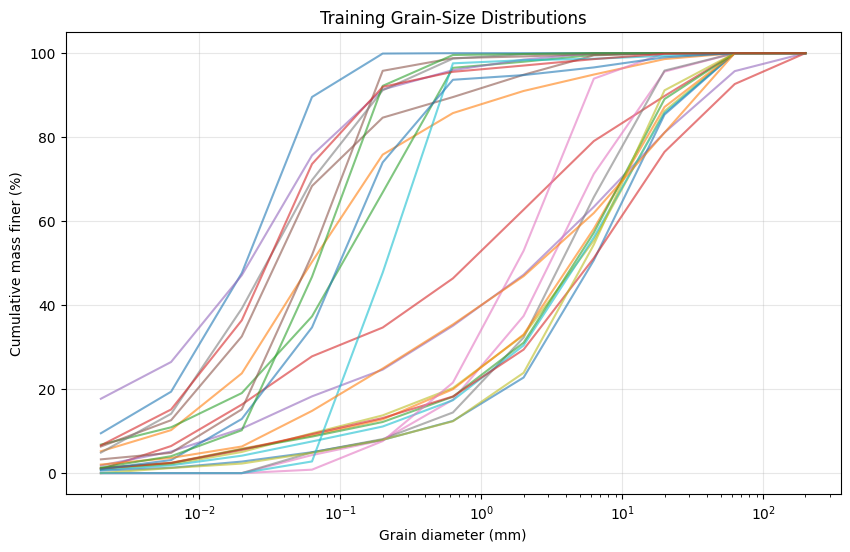

In [9]:
# look at the different samples to see the level of changes we are looking for.  Note x axis is on a log scale
grain_sizes = np.array([
    0.002, 0.0063, 0.02, 0.063, 0.2,
    0.63, 2, 6.3, 20, 63, 200
])

target_cols = [
    "0.002", "0.0063", "0.02", "0.063", "0.2",
    "0.63", "2", "6.3", "20", "63", "200"
]

plt.figure(figsize=(10, 6))

for _, row in labels.iterrows():
    plt.plot(
        grain_sizes,
        row[target_cols].astype(float),
        alpha=0.6
    )

plt.xscale("log")
plt.xlabel("Grain diameter (mm)")
plt.ylabel("Cumulative mass finer (%)")
plt.title("Training Grain-Size Distributions")
plt.grid(True, alpha=0.3)
plt.show()
# Looks like two main clusters those with small grain that move up quickly and those with larger grains that move up slower

In [12]:
image_files = list(TRAIN_IMAGES.glob("*.jpg"))

print("Total training images:", len(image_files))

for f in image_files[:10]:
    print(f.name)
# Get number of images and naming convention

Total training images: 127
Motorola_Edge_H030_04.jpg
Motorola_Edge_H037_01.jpg
Motorola_Edge_H038_03.jpg
Motorola_Edge_H030_03.jpg
Motorola_Edge_H037_02.jpg
Motorola_Edge_H183_04.jpg
Motorola_Edge_H366_03.jpg
Motorola_Edge_H183_02.jpg
Motorola_Edge_H037_03.jpg
Motorola_Edge_H368_04.jpg


In [13]:
ppm = pd.read_csv(PPM_FILE)

print("Shape:", ppm.shape)
display(ppm)
# Identify cameras, pretty large variation in ppm also, 2 phones and three cameras.

Shape: (5, 5)


,phone,camera,width,height,ppm
0,iPhone 14,iPhone 14,4032,3024,13.942
1,iPhone 16,iPhone 16,5712,4284,19.525
2,Motorola Edge,motorola edge 20,4000,1800,11.492
3,Motorola Edge 60 Fusion,Motorola Edge 60 fusion,4096,2304,12.465
4,Samsung A52,SM-A525F,9248,6936,26.330


In [14]:
# match photo file name with sample
sample_ids = labels["sample_id"].astype(str).tolist()

records = []

for f in image_files:

    # Find which known sample ID occurs in the filename
    matches = [sid for sid in sample_ids if f"_{sid}_" in f.name]

    if len(matches) != 1:
        print("Problem parsing:", f.name, matches)
        continue

    sample_id = matches[0]

    records.append({
        "filename": f.name,
        "sample_id": sample_id
    })

images_df = pd.DataFrame(records)

print("Images parsed:", len(images_df))
display(images_df.head(10))

Images parsed: 127


,filename,sample_id
0,Motorola_Edge_H030_04.jpg,H030
1,Motorola_Edge_H037_01.jpg,H037
2,Motorola_Edge_H038_03.jpg,H038
3,Motorola_Edge_H030_03.jpg,H030
4,Motorola_Edge_H037_02.jpg,H037
5,Motorola_Edge_H183_04.jpg,H183
6,Motorola_Edge_H366_03.jpg,H366
7,Motorola_Edge_H183_02.jpg,H183
8,Motorola_Edge_H037_03.jpg,H037
9,Motorola_Edge_H368_04.jpg,H368


In [15]:
#Identify distrubution of photos so we can see how many pictures/sample.   Need to make sure that we separate all images from test/train for each sample
image_counts = (
    images_df
    .groupby("sample_id")
    .size()
    .sort_values()
)

display(image_counts)

print("Number of samples:", len(image_counts))
print("Min photos:", image_counts.min())
print("Max photos:", image_counts.max())
print("Mean photos:", image_counts.mean())

,0
sample_id,
H374,3
H637,3
H366,4
H126,4
H516,4
H666,4
H367,4
H368,5
H549,5


Number of samples: 24
Min photos: 3
Max photos: 8
Mean photos: 5.291666666666667


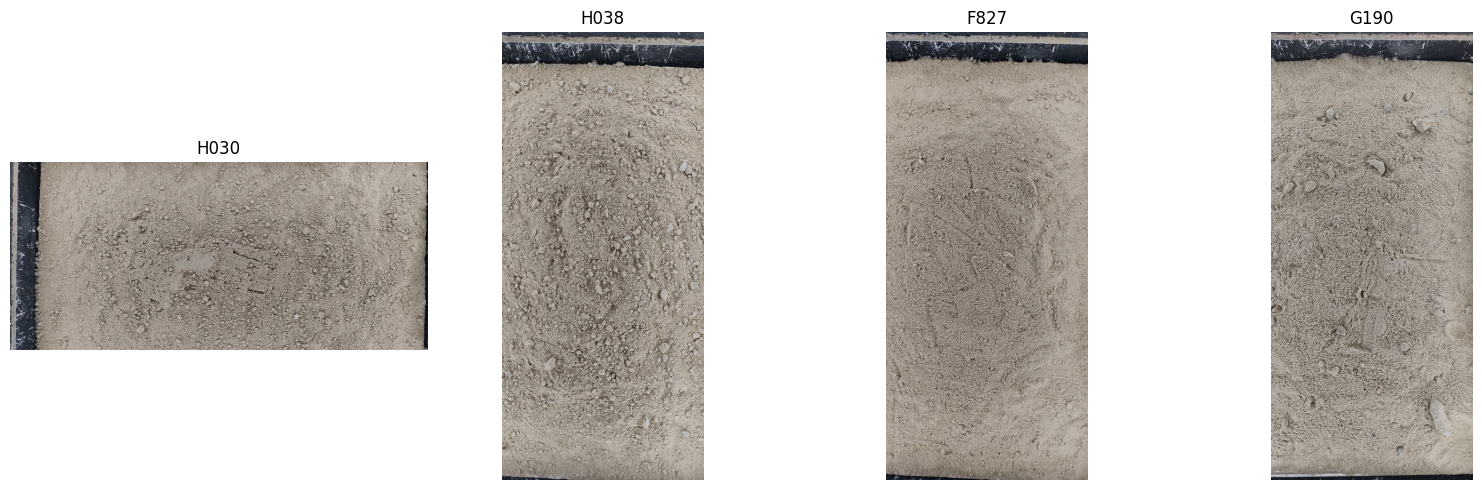

In [16]:
# Pick several soil samples
samples_to_view = ["H030", "H038", "F827", "G190"]

fig, axes = plt.subplots(1, len(samples_to_view), figsize=(16, 5))

for ax, sample_id in zip(axes, samples_to_view):

    file_name = images_df.loc[
        images_df["sample_id"] == sample_id,
        "filename"
    ].iloc[0]

    image_path = TRAIN_IMAGES / file_name
    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(sample_id)
    ax.axis("off")

plt.tight_layout()
plt.show()

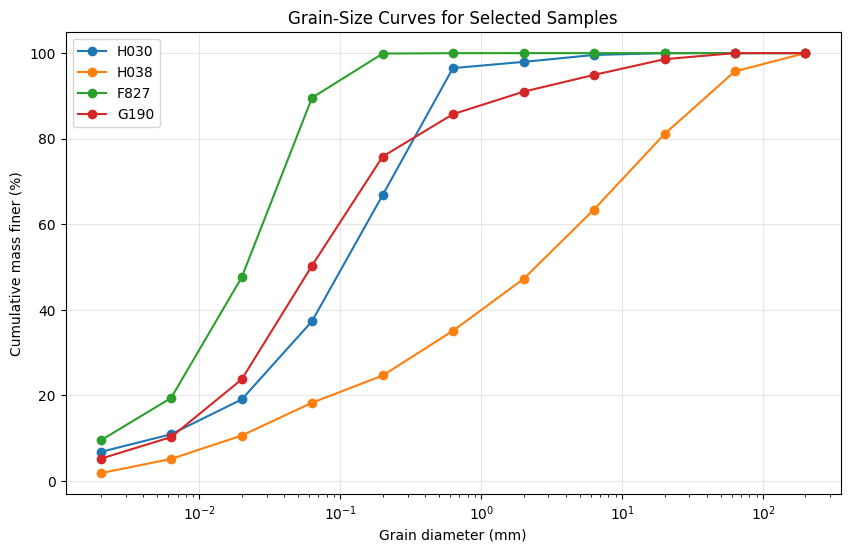

In [17]:
plt.figure(figsize=(10, 6))

for sample_id in samples_to_view:

    row = labels[labels["sample_id"] == sample_id].iloc[0]

    plt.plot(
        grain_sizes,
        row[target_cols].astype(float),
        marker="o",
        label=sample_id
    )

plt.xscale("log")
plt.xlabel("Grain diameter (mm)")
plt.ylabel("Cumulative mass finer (%)")
plt.title("Grain-Size Curves for Selected Samples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

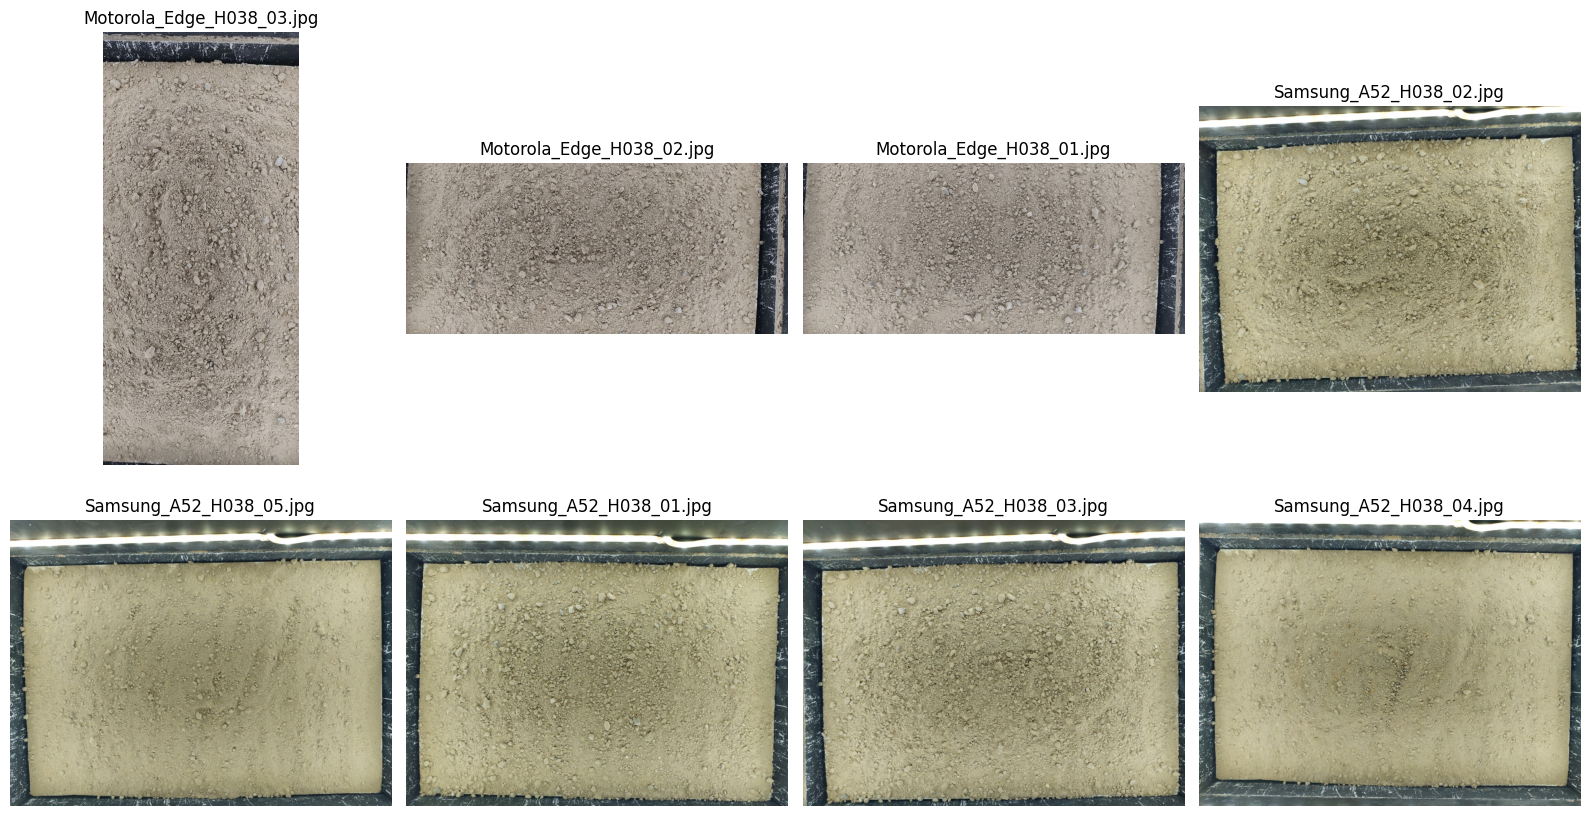

In [18]:
sample_id = "H038"

sample_files = images_df[
    images_df["sample_id"] == sample_id
]["filename"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for ax, filename in zip(axes.flat, sample_files):
    img = Image.open(TRAIN_IMAGES / filename)
    ax.imshow(img)
    ax.set_title(filename)
    ax.axis("off")

# Hide unused axes if necessary
for ax in axes.flat[len(sample_files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Look at predicting based on average soil compositions
# Log-spaced interval widths between the 11 grain-size support points
log_d = np.log10(grain_sizes)
interval_widths = np.diff(log_d)

def competition_emd(y_true, y_pred):
    """
    Approximate the competition's weighted EMD between two cumulative curves.

    y_true and y_pred are cumulative percentages at the 11 grain diameters.
    Lower is better.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Difference between cumulative curves over the first 10 support points
    cumulative_diff = np.abs(y_true[:-1] - y_pred[:-1])

    # Weight each interval by its log10 diameter width
    return np.sum(cumulative_diff * interval_widths)

In [20]:
baseline_results = []

for sample_id in labels["sample_id"]:

    # Held-out soil
    test_row = labels[labels["sample_id"] == sample_id].iloc[0]
    y_true = test_row[target_cols].astype(float).values

    # All other 23 soils
    train_rows = labels[labels["sample_id"] != sample_id]

    # Mean curve of the other 23 soils
    y_pred = train_rows[target_cols].astype(float).mean(axis=0).values

    # Score this held-out soil
    score = competition_emd(y_true, y_pred)

    baseline_results.append({
        "sample_id": sample_id,
        "emd": score
    })

baseline_df = pd.DataFrame(baseline_results)

display(baseline_df.sort_values("emd"))

print("Mean baseline EMD:", baseline_df["emd"].mean())
print("Median baseline EMD:", baseline_df["emd"].median())
print("Best soil:", baseline_df.loc[baseline_df["emd"].idxmin(), "sample_id"])
print("Worst soil:", baseline_df.loc[baseline_df["emd"].idxmax(), "sample_id"])

,sample_id,emd
3,H037,17.530141
4,H038,57.238248
21,H637,60.870387
20,H617,68.149804
2,H030,74.205118
1,G190,74.510404
19,H616,80.523602
16,H516,83.000774
11,H371,85.657659
6,H181,85.688611


Mean baseline EMD: 89.88886659893313
Median baseline EMD: 90.07229546329232
Best soil: H037
Worst soil: F827


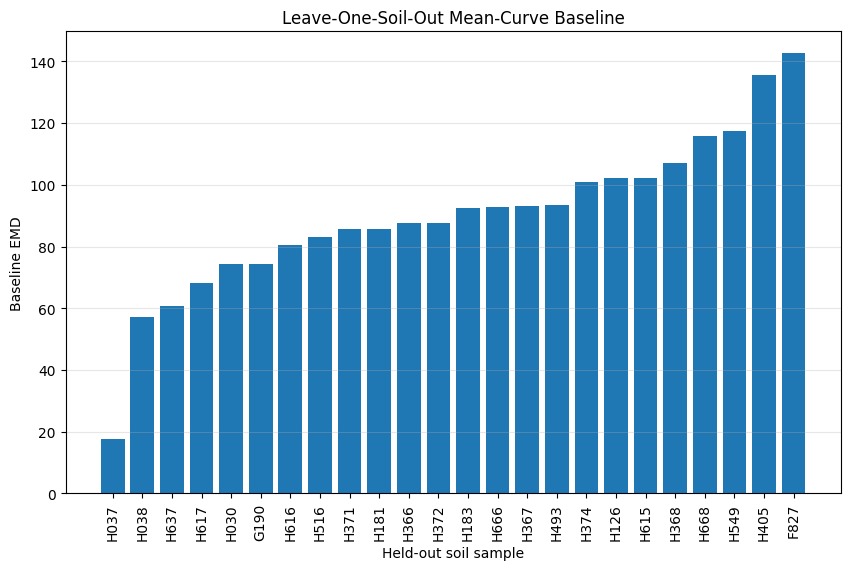

In [21]:
baseline_df_sorted = baseline_df.sort_values("emd")

plt.figure(figsize=(10, 6))
plt.bar(
    baseline_df_sorted["sample_id"],
    baseline_df_sorted["emd"]
)

plt.xticks(rotation=90)
plt.xlabel("Held-out soil sample")
plt.ylabel("Baseline EMD")
plt.title("Leave-One-Soil-Out Mean-Curve Baseline")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [22]:
from sklearn.model_selection import KFold

# Get the 24 unique soil IDs
sample_ids = labels["sample_id"].unique()

kf = KFold(
    n_splits=6,
    shuffle=True,
    random_state=42
)

fold_assignments = []

for fold, (train_idx, val_idx) in enumerate(kf.split(sample_ids), start=1):

    train_samples = sample_ids[train_idx]
    val_samples = sample_ids[val_idx]

    fold_assignments.append({
        "fold": fold,
        "train_samples": train_samples,
        "val_samples": val_samples
    })

    print(f"\nFold {fold}")
    print("Train:", train_samples)
    print("Validation:", val_samples)


Fold 1
Train: ['G190' 'H030' 'H037' 'H038' 'H126' 'H181' 'H183' 'H367' 'H368' 'H371'
 'H372' 'H374' 'H405' 'H493' 'H549' 'H616' 'H617' 'H637' 'H666' 'H668']
Validation: ['F827' 'H366' 'H516' 'H615']

Fold 2
Train: ['F827' 'H030' 'H037' 'H038' 'H126' 'H181' 'H183' 'H366' 'H368' 'H372'
 'H405' 'H493' 'H516' 'H549' 'H615' 'H616' 'H617' 'H637' 'H666' 'H668']
Validation: ['G190' 'H367' 'H371' 'H374']

Fold 3
Train: ['F827' 'G190' 'H037' 'H038' 'H181' 'H183' 'H366' 'H367' 'H368' 'H371'
 'H374' 'H405' 'H493' 'H516' 'H549' 'H615' 'H616' 'H617' 'H666' 'H668']
Validation: ['H030' 'H126' 'H372' 'H637']

Fold 4
Train: ['F827' 'G190' 'H030' 'H126' 'H181' 'H183' 'H366' 'H367' 'H368' 'H371'
 'H372' 'H374' 'H405' 'H516' 'H549' 'H615' 'H616' 'H617' 'H637' 'H668']
Validation: ['H037' 'H038' 'H493' 'H666']

Fold 5
Train: ['F827' 'G190' 'H030' 'H037' 'H038' 'H126' 'H181' 'H366' 'H367' 'H368'
 'H371' 'H372' 'H374' 'H405' 'H493' 'H516' 'H615' 'H616' 'H637' 'H666']
Validation: ['H183' 'H549' 'H617' 'H668']


In [23]:
fold = fold_assignments[0]

train_df = images_df[
    images_df["sample_id"].isin(fold["train_samples"])
].copy()

val_df = images_df[
    images_df["sample_id"].isin(fold["val_samples"])
].copy()

print("Training soils:", train_df["sample_id"].nunique())
print("Validation soils:", val_df["sample_id"].nunique())

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training soils: 20
Validation soils: 4
Training images: 109
Validation images: 18


In [24]:
train_ids = set(train_df["sample_id"])
val_ids = set(val_df["sample_id"])

print("Overlap:", train_ids.intersection(val_ids))

Overlap: set()
